# IFB 07 — Feature Contract & Input Domain

Validate exact compatibility with the frozen model metadata and flag unusually extreme operational values.

In [1]:
# Import libraries
from pathlib import Path
import sys
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# Define config paths
PROJECT_ROOT = Path.cwd()
while (
    not (PROJECT_ROOT / "src").exists()
    and PROJECT_ROOT != PROJECT_ROOT.parent
):
    PROJECT_ROOT = PROJECT_ROOT.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

CONFIG_PATH = (
    PROJECT_ROOT
    / "configs"
    / "inference_feature_builder.yaml"
)

print("Project root:", PROJECT_ROOT)
print("IFB config:", CONFIG_PATH)

Project root: e:\jcuenca\OneDrive - GUSCanada\5toTerm\01_Capstone\DataLocal\ontario-electricity-peak-risk
IFB config: e:\jcuenca\OneDrive - GUSCanada\5toTerm\01_Capstone\DataLocal\ontario-electricity-peak-risk\configs\inference_feature_builder.yaml


In [3]:
# Import module for running inference_feature_builder
from src.ontario_peak_risk.inference_feature_builder.io import (
    load_ifb_config,
    resolve_path,
    load_project_history,
    load_operational_updates,
    combine_observed_history,
    latest_weather_forecast_for_origin,
)
from src.ontario_peak_risk.inference_feature_builder.builder import (
    build_feature_matrix,
    load_model_contracts,
    expected_features,
    feature_contract_report,
)
from src.ontario_peak_risk.inference_feature_builder.validation import (
    demand_history_requirements,
    validate_weather_grid,
    domain_reference,
    domain_check,
)
from src.ontario_peak_risk.inference_feature_builder.plotting import (
    feature_completeness_heatmap,
    domain_warning_plot,
)

### Define the Origin Time for forecasting
- This is the date from which consumption for the next 24 hours is forecasted.
- This value must be changed according with the requirement

In [4]:
# Define the Origin time and FSAs
Origin_Time = "2026-03-25 23:00:00"

In [5]:
config, project_root = load_ifb_config(CONFIG_PATH)

# Change only this value for another operational simulation.
FORECAST_ORIGIN = pd.Timestamp(Origin_Time)
FSAS = list(config["inference"]["fsas"])

project_history = load_project_history(config, project_root)
updates = load_operational_updates(config, project_root)

observed_history, duplicate_report = combine_observed_history(
    project_history,
    updates["demand"],
    updates["weather_history"],
    config,
)

forecast_weather = latest_weather_forecast_for_origin(
    updates["weather_forecasts"],
    FORECAST_ORIGIN,
    FSAS,
    config,
)

print("Historical project maximum:", project_history["timestamp"].max())
print("Combined observed maximum:", observed_history["timestamp"].max())
print("Forecast origin:", FORECAST_ORIGIN)
display(updates["inventory"])

Historical project maximum: 2025-12-31 23:00:00
Combined observed maximum: 2026-04-30 23:00:00
Forecast origin: 2026-03-25 23:00:00


,source_type,file,path,rows,min_timestamp,max_timestamp
0,demand_update,hourly_consumption_fsa_L4T_20260101-20260430.csv,E:\jcuenca\OneDrive - GUSCanada\5toTerm\01_Cap...,2880,2026-01-01,2026-04-30 23:00:00
1,demand_update,hourly_consumption_fsa_M5R_20260101-20260430.csv,E:\jcuenca\OneDrive - GUSCanada\5toTerm\01_Cap...,2880,2026-01-01,2026-04-30 23:00:00
2,demand_update,hourly_consumption_fsa_M5S_20260101-20260430.csv,E:\jcuenca\OneDrive - GUSCanada\5toTerm\01_Cap...,2880,2026-01-01,2026-04-30 23:00:00
3,demand_update,hourly_consumption_fsa_M6G_20260101-20260430.csv,E:\jcuenca\OneDrive - GUSCanada\5toTerm\01_Cap...,2880,2026-01-01,2026-04-30 23:00:00
4,demand_update,hourly_consumption_fsa_M9R_20260101-20260430.csv,E:\jcuenca\OneDrive - GUSCanada\5toTerm\01_Cap...,2880,2026-01-01,2026-04-30 23:00:00
5,demand_update,hourly_consumption_fsa_M9W_20260101-20260430.csv,E:\jcuenca\OneDrive - GUSCanada\5toTerm\01_Cap...,2880,2026-01-01,2026-04-30 23:00:00
6,weather_forecast,weather_forecast_L4T_20250701-20260728.csv,E:\jcuenca\OneDrive - GUSCanada\5toTerm\01_Cap...,9432,2025-07-01,2026-07-28 23:00:00
7,weather_forecast,weather_forecast_M5R_20250701-20260728.csv,E:\jcuenca\OneDrive - GUSCanada\5toTerm\01_Cap...,9432,2025-07-01,2026-07-28 23:00:00
8,weather_forecast,weather_forecast_M5S_20250701-20260728.csv,E:\jcuenca\OneDrive - GUSCanada\5toTerm\01_Cap...,9432,2025-07-01,2026-07-28 23:00:00
9,weather_forecast,weather_forecast_M6G_20250701-20260728.csv,E:\jcuenca\OneDrive - GUSCanada\5toTerm\01_Cap...,9432,2025-07-01,2026-07-28 23:00:00


In [6]:
# Re-run the availability checks here so IFB_07 does not depend on IFB_02.
demand_coverage, missing_demand = demand_history_requirements(
    observed_history, FORECAST_ORIGIN, FSAS, config
)
weather_coverage, missing_weather = validate_weather_grid(
    forecast_weather, FORECAST_ORIGIN, FSAS, config
)

display(demand_coverage)
display(weather_coverage)

if demand_coverage["status"].eq("FAIL").any():
    display(missing_demand.head(50))
    raise ValueError("Demand history validation failed.")

if weather_coverage["status"].eq("FAIL").any():
    display(missing_weather.head(50))
    raise ValueError("Weather grid validation failed.")

,fsa,required_start,required_end,required_hours,available_hours,missing_hours,latest_available_demand,gap_from_latest_to_origin_hours,status
0,L4T,2026-03-18 23:00:00,2026-03-25 23:00:00,169,169,0,2026-03-25 23:00:00,0.0,PASS
1,M5R,2026-03-18 23:00:00,2026-03-25 23:00:00,169,169,0,2026-03-25 23:00:00,0.0,PASS
2,M5S,2026-03-18 23:00:00,2026-03-25 23:00:00,169,169,0,2026-03-25 23:00:00,0.0,PASS
3,M6G,2026-03-18 23:00:00,2026-03-25 23:00:00,169,169,0,2026-03-25 23:00:00,0.0,PASS
4,M9R,2026-03-18 23:00:00,2026-03-25 23:00:00,169,169,0,2026-03-25 23:00:00,0.0,PASS
5,M9W,2026-03-18 23:00:00,2026-03-25 23:00:00,169,169,0,2026-03-25 23:00:00,0.0,PASS


,fsa,required_rows_h0_h24,available_complete_rows,missing_rows,status
0,L4T,25,25,0,PASS
1,M5R,25,25,0,PASS
2,M5S,25,25,0,PASS
3,M6G,25,25,0,PASS
4,M9R,25,25,0,PASS
5,M9W,25,25,0,PASS


In [7]:
generated = build_feature_matrix(
    observed_history,
    forecast_weather,
    FORECAST_ORIGIN,
    FSAS,
    config=config,
)

print("Generated rows:", len(generated))
print("Expected rows:", len(FSAS) * 24)
print("Horizons:", generated["horizon"].min(), "to", generated["horizon"].max())
display(generated.head(12))

Generated rows: 144
Expected rows: 144
Horizons: 1 to 24


,fsa,forecast_origin,horizon,target_timestamp,target_hour,target_weekday,target_month,target_is_weekend,target_hour_sin,target_hour_cos,...,origin_rolling_mean_24h,origin_rolling_std_24h,origin_rolling_mean_168h,_rf_origin_rolling_mean_24h,_rf_origin_rolling_std_24h,_rf_origin_rolling_mean_168h,origin__Temp (°C),origin__Rel Hum (%),origin__Stn Press (kPa),origin__reported_premise_count
0,L4T,2026-03-25 23:00:00,1,2026-03-26 00:00:00,0,3,3,0,0.000000,1.000000e+00,...,10760.999661,1427.542287,11251.270891,10748.308175,1437.684353,11243.844103,2.7,82.0,99.0,8567.0
1,L4T,2026-03-25 23:00:00,2,2026-03-26 01:00:00,1,3,3,0,0.258819,9.659258e-01,...,10760.999661,1427.542287,11251.270891,10748.308175,1437.684353,11243.844103,2.7,82.0,99.0,8567.0
2,L4T,2026-03-25 23:00:00,3,2026-03-26 02:00:00,2,3,3,0,0.500000,8.660254e-01,...,10760.999661,1427.542287,11251.270891,10748.308175,1437.684353,11243.844103,2.7,82.0,99.0,8567.0
3,L4T,2026-03-25 23:00:00,4,2026-03-26 03:00:00,3,3,3,0,0.707107,7.071068e-01,...,10760.999661,1427.542287,11251.270891,10748.308175,1437.684353,11243.844103,2.7,82.0,99.0,8567.0
4,L4T,2026-03-25 23:00:00,5,2026-03-26 04:00:00,4,3,3,0,0.866025,5.000000e-01,...,10760.999661,1427.542287,11251.270891,10748.308175,1437.684353,11243.844103,2.7,82.0,99.0,8567.0
5,L4T,2026-03-25 23:00:00,6,2026-03-26 05:00:00,5,3,3,0,0.965926,2.588190e-01,...,10760.999661,1427.542287,11251.270891,10748.308175,1437.684353,11243.844103,2.7,82.0,99.0,8567.0
6,L4T,2026-03-25 23:00:00,7,2026-03-26 06:00:00,6,3,3,0,1.000000,6.123234e-17,...,10760.999661,1427.542287,11251.270891,10748.308175,1437.684353,11243.844103,2.7,82.0,99.0,8567.0
7,L4T,2026-03-25 23:00:00,8,2026-03-26 07:00:00,7,3,3,0,0.965926,-2.588190e-01,...,10760.999661,1427.542287,11251.270891,10748.308175,1437.684353,11243.844103,2.7,82.0,99.0,8567.0
8,L4T,2026-03-25 23:00:00,9,2026-03-26 08:00:00,8,3,3,0,0.866025,-5.000000e-01,...,10760.999661,1427.542287,11251.270891,10748.308175,1437.684353,11243.844103,2.7,82.0,99.0,8567.0
9,L4T,2026-03-25 23:00:00,10,2026-03-26 09:00:00,9,3,3,0,0.707107,-7.071068e-01,...,10760.999661,1427.542287,11251.270891,10748.308175,1437.684353,11243.844103,2.7,82.0,99.0,8567.0


In [8]:
artifacts = resolve_path(project_root, config["paths"]["artifacts_dir"])
contracts = load_model_contracts(artifacts)

contract = pd.concat(
    [
        feature_contract_report(
            generated, contracts["rf"], model_name="RandomForestRegressor"
        ),
        feature_contract_report(
            generated, contracts["xgb"], model_name="XGBoostClassifier"
        ),
    ],
    ignore_index=True,
)

display(contract)
print("PASS:", int(contract["status"].eq("PASS").sum()))
print("WARN:", int(contract["status"].eq("WARN").sum()))
print("FAIL:", int(contract["status"].eq("FAIL").sum()))

if contract["status"].eq("FAIL").any():
    display(contract.loc[contract["status"].eq("FAIL")])
    raise ValueError("Frozen feature contract validation failed.")

,model,feature,status,detail
0,RandomForestRegressor,target_hour,PASS,available
1,RandomForestRegressor,target_weekday,PASS,available
2,RandomForestRegressor,target_month,PASS,available
3,RandomForestRegressor,target_is_weekend,PASS,available
4,RandomForestRegressor,target_hour_sin,PASS,available
5,RandomForestRegressor,target_hour_cos,PASS,available
6,RandomForestRegressor,target_weekday_sin,PASS,available
7,RandomForestRegressor,target_weekday_cos,PASS,available
8,RandomForestRegressor,target_month_sin,PASS,available
9,RandomForestRegressor,target_month_cos,PASS,available


PASS: 44
WARN: 0
FAIL: 0


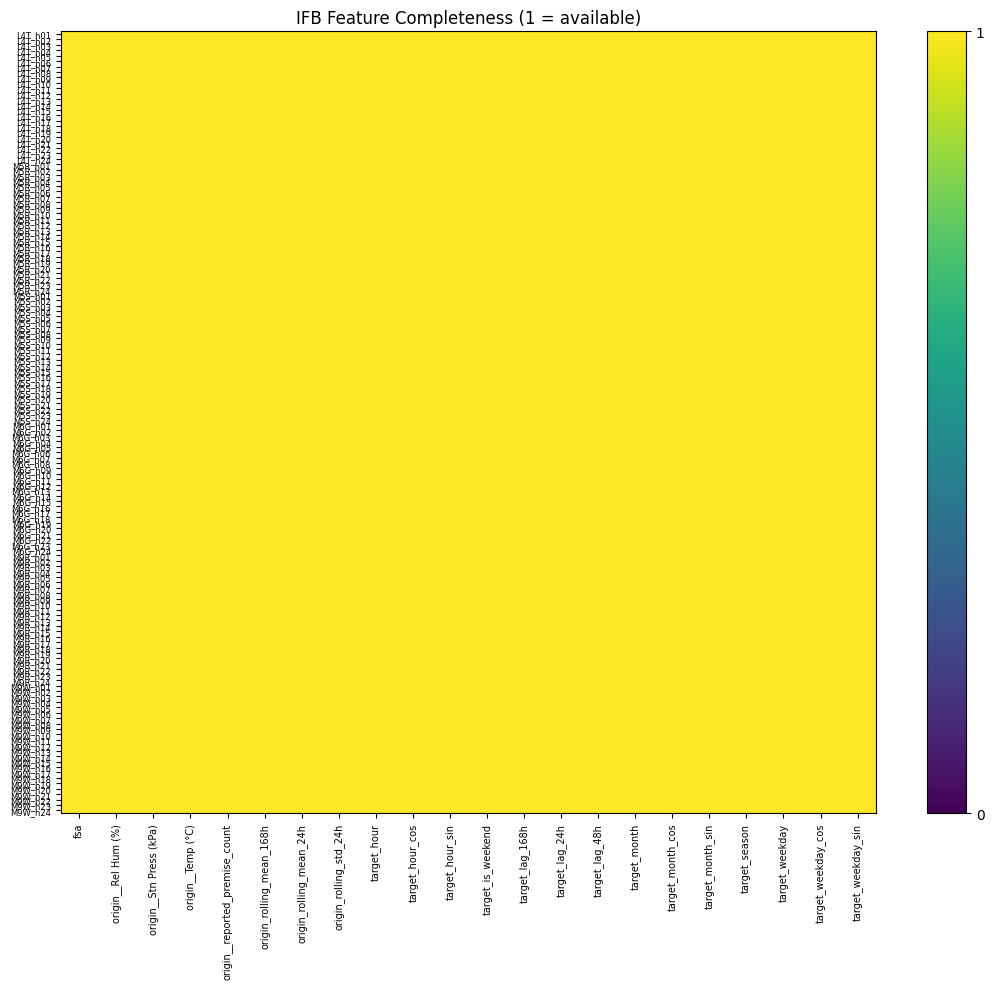

In [9]:
all_features = sorted(
    set(expected_features(contracts["rf"]))
    | set(expected_features(contracts["xgb"]))
)
feature_completeness_heatmap(generated, all_features)
plt.show()

,variable,historical_min,historical_p01,historical_p99,historical_max
0,total_consumption_kwh,1377.7,2586.329,21178.17,33712.20
1,Temp (°C),-21.8,-11.900,29.40,35.80
2,Rel Hum (%),14.0,28.000,100.00,100.00
3,Stn Press (kPa),95.7,97.700,101.72,103.25


""


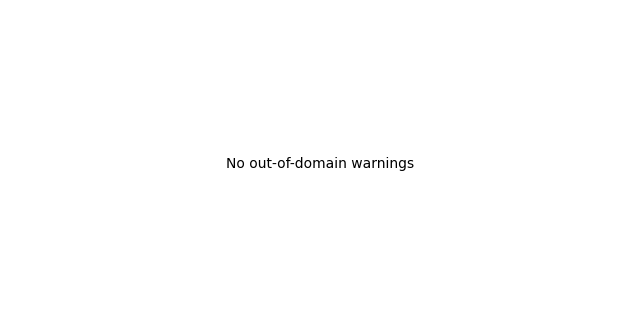

IFB_07 RESULT: PASS
The 2026 operational feature matrix matches the frozen model contract.


In [10]:
# Domain reference intentionally remains based on the original historical
# project period, so 2026 inputs are compared against the training-era domain.
reference = domain_reference(project_history, config)

domain_input = generated.rename(
    columns={
        "origin__Temp (°C)": "Temp (°C)",
        "origin__Rel Hum (%)": "Rel Hum (%)",
        "origin__Stn Press (kPa)": "Stn Press (kPa)",
    }
)

domain_report = domain_check(
    domain_input,
    reference,
    context="post_holdout_operational_simulation",
)

display(reference)
display(domain_report.head(50))
domain_warning_plot(domain_report)
plt.show()

print("IFB_07 RESULT: PASS")
print("The 2026 operational feature matrix matches the frozen model contract.")


`CAUTION` means the input is outside the historical 1st–99th percentile range.
`OUT_OF_RANGE` means it is outside the historical minimum/maximum. These
warnings should be visible in the final application; they do not silently
change the model.
